In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from concurrent.futures import ThreadPoolExecutor



In [2]:
import os
from concurrent.futures import ThreadPoolExecutor
from itertools import chain

class XRayDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.mask_paths = []
        
        def process_category(category):
            category_path = os.path.join(root_dir, category)
            if not os.path.isdir(category_path):
                return []
            
            img_dir = os.path.join(category_path, "images")
            mask_dir = os.path.join(category_path, "masks")
            
            if not (os.path.exists(img_dir) and os.path.exists(mask_dir)):
                return []
            
            img_names = sorted(os.scandir(img_dir), key=lambda x: x.name)
            mask_names = sorted(os.scandir(mask_dir), key=lambda x: x.name)
            
            valid_pairs = [
                (os.path.join(img_dir, img.name), os.path.join(mask_dir, mask.name))
                for img, mask in zip(img_names, mask_names)
                if os.path.exists(os.path.join(mask_dir, mask.name))
            ]
            return valid_pairs
        
        # Több szálon történő bejárás
        with ThreadPoolExecutor() as executor:
            results = executor.map(process_category, os.listdir(root_dir))
        
        # Összefűzzük az eredményeket
        file_pairs = list(chain.from_iterable(results))
        self.image_paths, self.mask_paths = zip(*file_pairs) if file_pairs else ([], [])

        # Előre betöltjük az adatokat a RAM-ba párhuzamosan
        with ThreadPoolExecutor() as executor:
            self.images = list(executor.map(lambda p: Image.open(p).convert("L"), self.image_paths))
            self.masks = list(executor.map(lambda p: Image.open(p).convert("L"), self.mask_paths))
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        image = self.images[idx]
        mask = self.masks[idx]
        
        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)
        
        return image, mask


In [3]:
# Transzformációk (Tensor formátum és normalizálás)
transform = transforms.Compose([
    transforms.Resize((256, 256)),  # Átméretezés 256x256-re
    transforms.ToTensor(),          # Tensor formátum
    # transforms.Normalize(mean=[0.5], std=[0.5])  # Normalizálás -1 és 1 közé
])

# Dataset és DataLoader inicializálás
root_dir = "/kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset"
dataset = XRayDataset(root_dir, transform=transform)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

In [4]:
# Vizualizálás (5 maszkolt röntgenkép, középre igazítva)
def show_images_with_masks(dataset, num_images=5):
    fig, axes = plt.subplots(1, num_images, figsize=(num_images * 5, 5))
    for i in range(num_images):
        image, mask = dataset[i]
        image_np = image.squeeze().numpy()
        mask_np = mask.squeeze().numpy()
        
        # Biztosítjuk, hogy a maszk mérete egyezzen a képpel
        if mask_np.shape != image_np.shape:
            mask_np = np.array(Image.fromarray(mask_np).resize(image_np.shape[::-1], Image.BILINEAR))
        
        # Maszk overlay
        axes[i].imshow(image_np, cmap='gray')
        axes[i].imshow(mask_np, cmap='jet', alpha=0.5)  # Átlátszó maszk
        axes[i].set_title("X-ray with Mask")
        axes[i].axis("off")
    
    plt.tight_layout()
    plt.show()

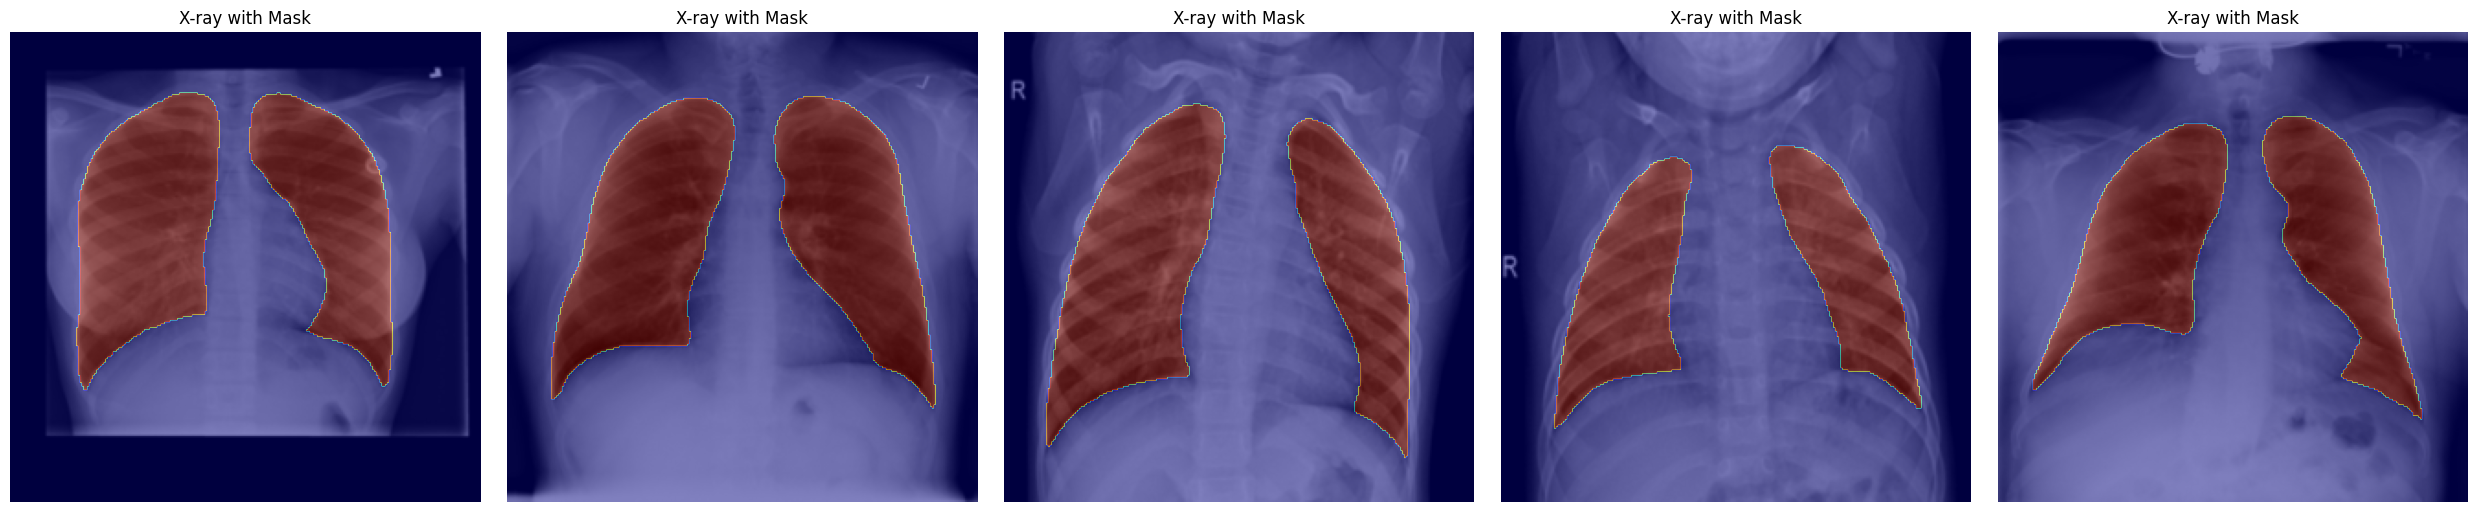

In [5]:
# Megjelenítés
show_images_with_masks(dataset)

In [6]:
# Train, valid, test split
train_size = int(0.8 * len(dataset))
valid_size = int(0.10 * len(dataset))
test_size = len(dataset) - train_size - valid_size

train_dataset, valid_dataset, test_dataset = random_split(dataset, [train_size, valid_size, test_size])

num_workers = os.cpu_count()


# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=num_workers)
valid_loader = DataLoader(valid_dataset, batch_size=16, shuffle=False, num_workers=num_workers)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=num_workers)

# UNet

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import segmentation_models_pytorch as smp
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset, random_split
import matplotlib.pyplot as plt
from sklearn.metrics import jaccard_score, f1_score
from PIL import Image
from concurrent.futures import ThreadPoolExecutor
from itertools import chain

# Eszköz beállítása (GPU/CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# UNet modell előre betanított backbone-nal
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=1,
    classes=1,
    activation=None,  # Sigmoid a loss függvényben kezelve
).to(device)

# Optimalizáló és veszteségfüggvény
optimizer = optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.BCEWithLogitsLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# Adat augmentáció
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])

# Teszteléshez szükséges metrikák

def calculate_metrics(outputs, masks):
    outputs = (torch.sigmoid(outputs) > 0.5).float()
    masks = masks.int().cpu().numpy().flatten()
    outputs = outputs.int().cpu().numpy().flatten()
    iou = jaccard_score(masks, outputs)
    dice = f1_score(masks, outputs)
    return iou, dice

# Edzés
scaler = torch.amp.GradScaler()
n_epochs = 10

for epoch in range(n_epochs):
    model.train()
    train_loss = 0.0
    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast(device_type='cuda'):
            outputs = model(images)
            loss = criterion(outputs, masks)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    scheduler.step(train_loss)
    print(f"Epoch [{epoch+1}/{n_epochs}], Loss: {train_loss:.4f}")

# Tesztelés
model.eval()
test_loss = 0.0
total_iou = 0.0
total_dice = 0.0

with torch.no_grad():
    for images, masks in test_loader:
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        loss = criterion(outputs, masks)
        test_loss += loss.item()
        iou, dice = calculate_metrics(outputs, masks)
        total_iou += iou
        total_dice += dice

num_batches = len(test_loader)
test_loss /= num_batches
total_iou /= num_batches
total_dice /= num_batches

print(f"Test Loss: {test_loss:.4f}")
print(f"Average IoU: {total_iou:.4f}")
print(f"Average Dice Score: {total_dice:.4f}")

print("Tréning és tesztelés befejezve!")


In [21]:
# Tesztelés
model.eval()
test_loss = 0.0
total_iou = 0.0
total_dice = 0.0

with torch.no_grad():
    for images, masks in test_loader:
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        loss = criterion(outputs, masks)
        test_loss += loss.item()
        iou, dice = calculate_metrics(outputs, masks)
        total_iou += iou
        total_dice += dice

num_batches = len(test_loader)
test_loss /= num_batches
total_iou /= num_batches
total_dice /= num_batches

print(f"Test Loss: {test_loss:.4f}")
print(f"Average IoU: {total_iou:.4f}")
print(f"Average Dice Score: {total_dice:.4f}")

print("Tréning és tesztelés befejezve!")

Test Loss: 0.0112
Average IoU: 0.9818
Average Dice Score: 0.9908
Tréning és tesztelés befejezve!


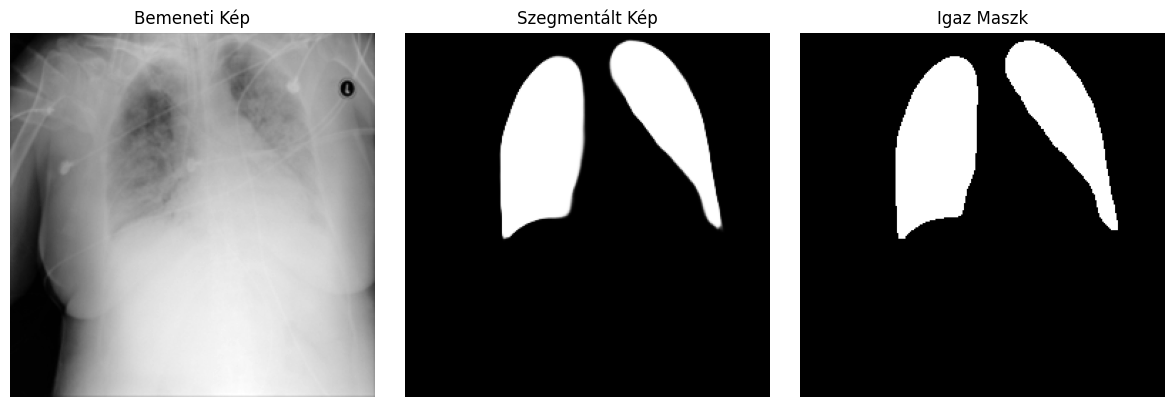

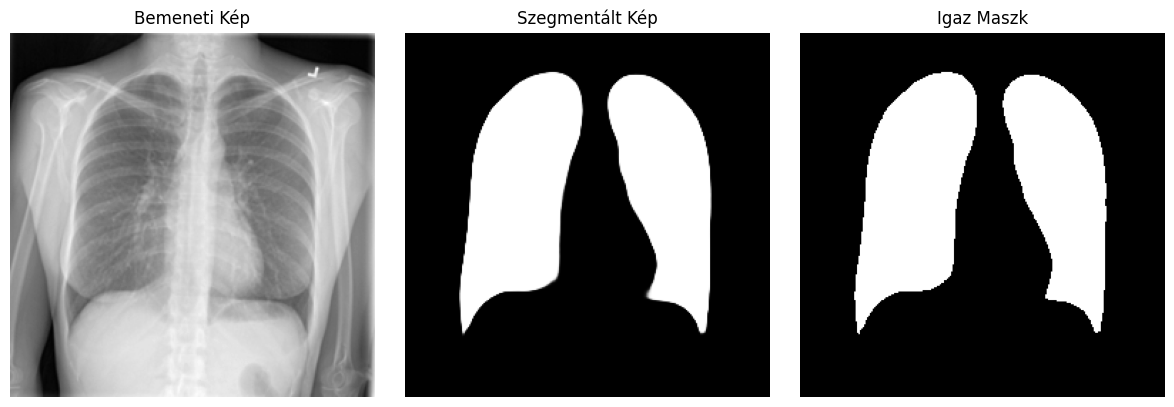

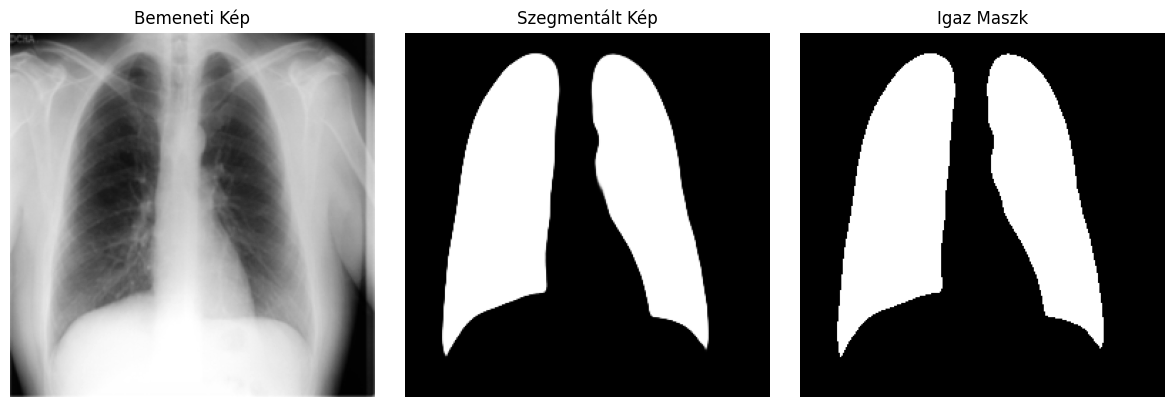

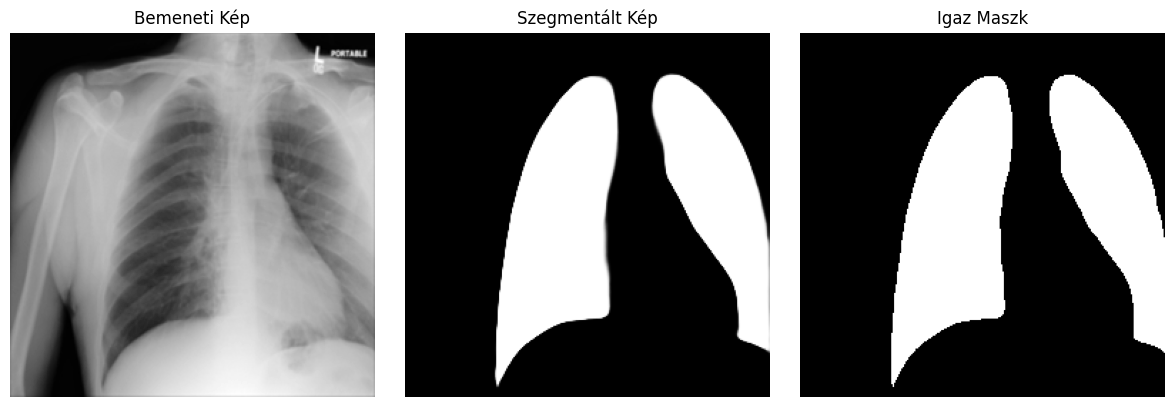

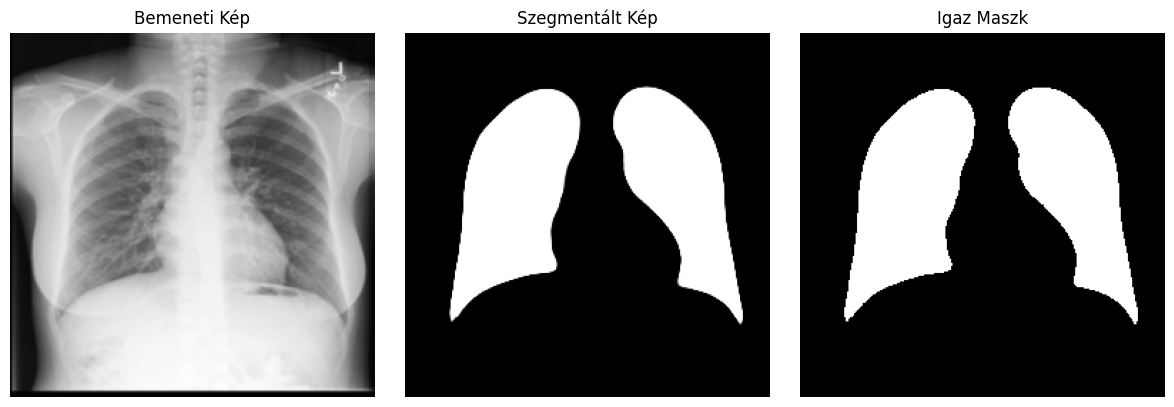

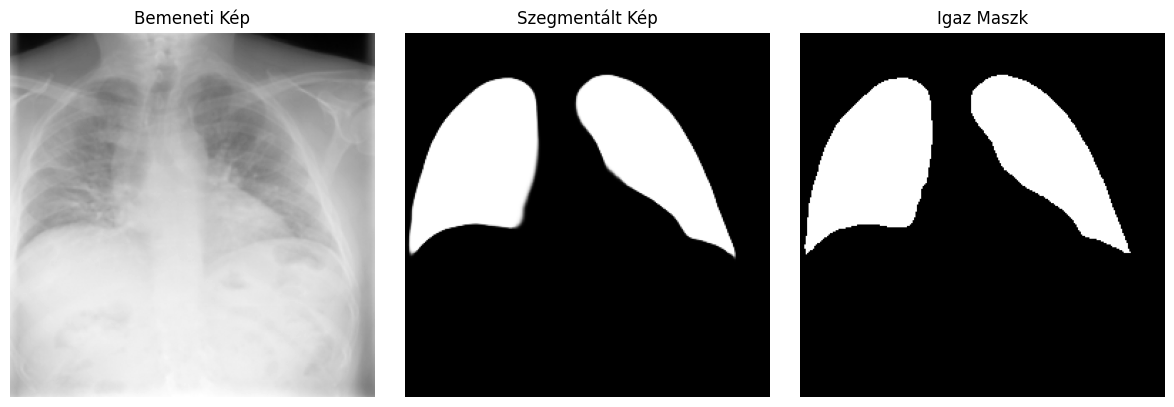

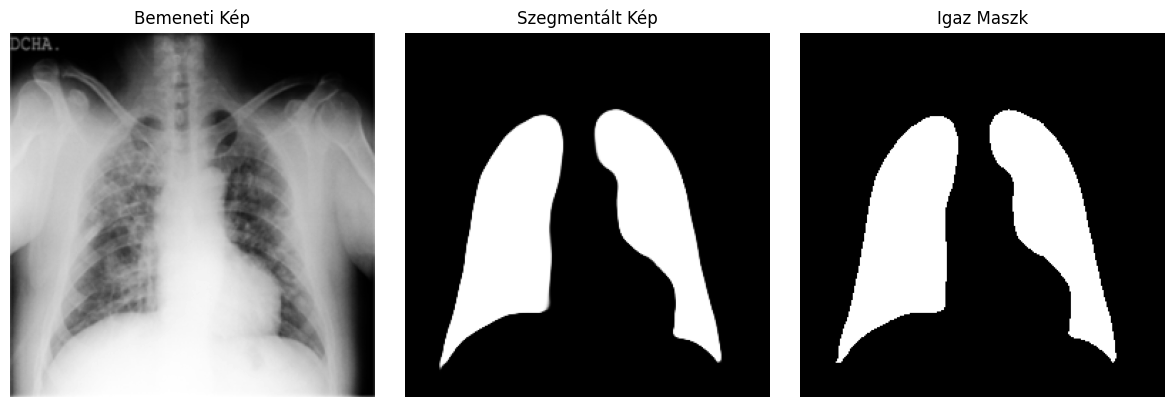

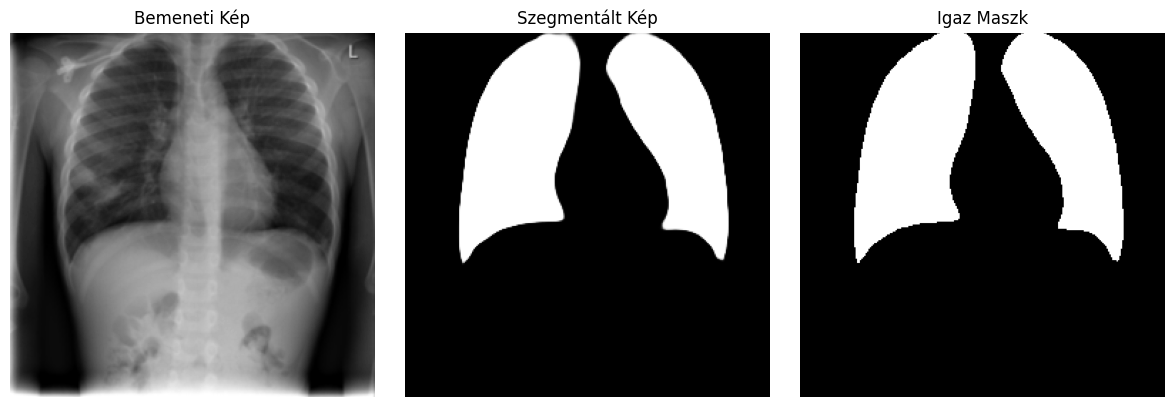

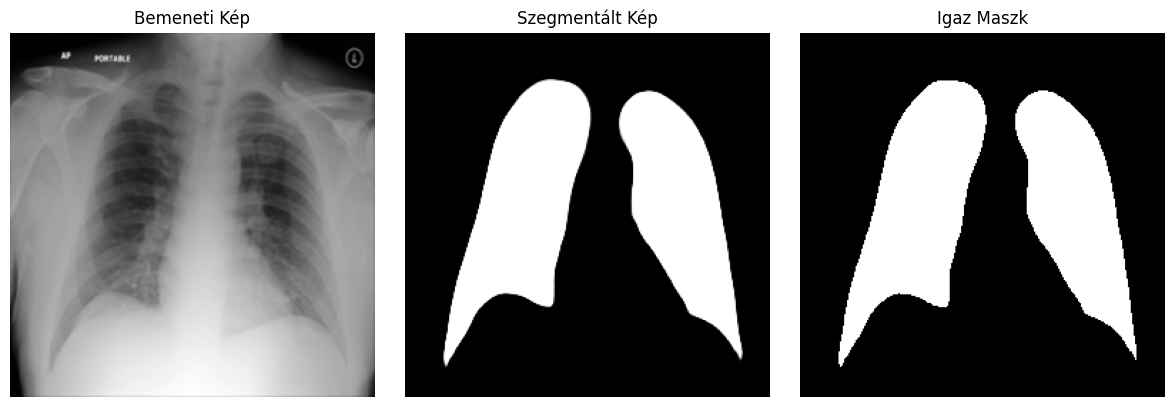

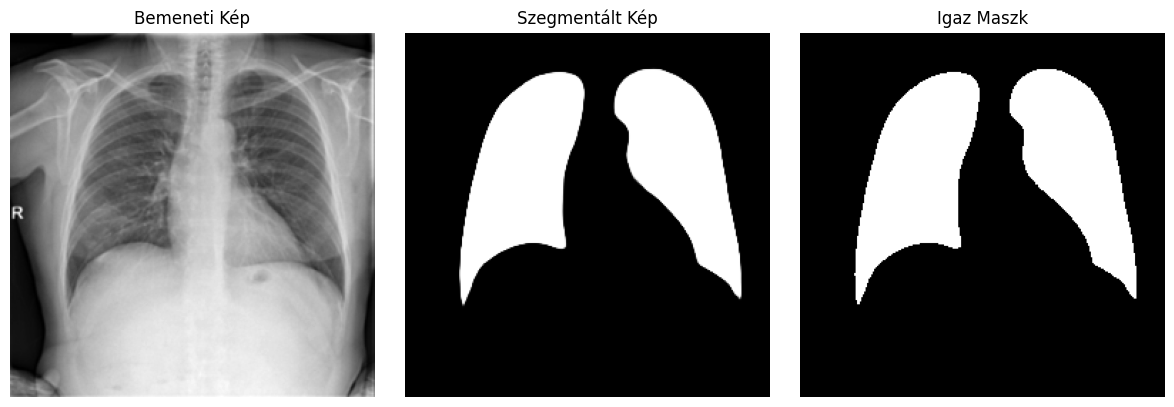

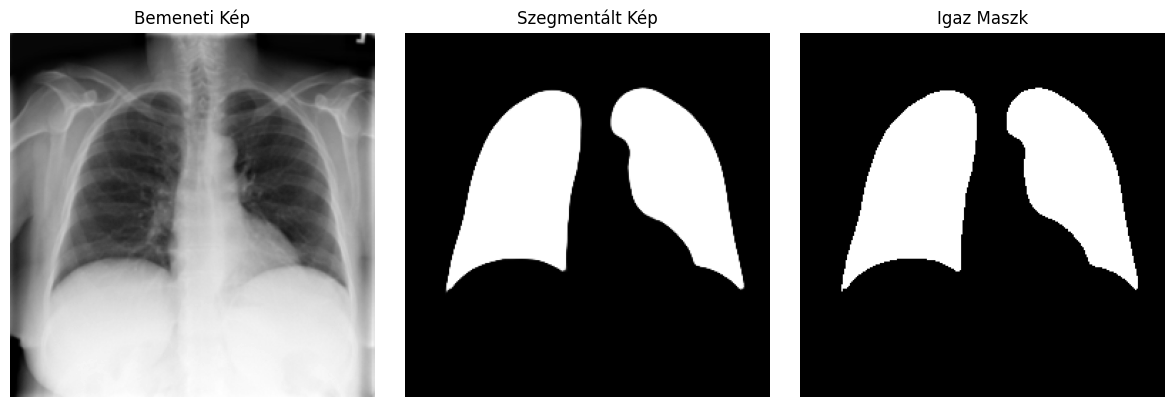

In [20]:
import torch
import matplotlib.pyplot as plt
from torchvision import transforms

# A modell eval módban (figyelmen kívül hagyja a dropout-ot, batch norm-ot)
model.eval()

# Tesztelés
for idx, (image, mask) in enumerate(test_loader):
    image, mask = image.to(device), mask.to(device)

    # A modell előrejelzése
    with torch.no_grad():  # Ne számoljon gradienssel
        output = model(image)
        output = torch.sigmoid(output)  # Bináris kimenet (0-1 valószínűség)
        output = output.squeeze(0)  # Kivéve a batch dimenziót
        output = output.cpu().numpy()  # NumPy array-t csinálunk a képből

        # A kép megjelenítése
        plt.figure(figsize=(12, 4))
        
        # Bemeneti kép (válaszd ki az első képet a batch-ból)
        plt.subplot(1, 3, 1)
        plt.imshow(image[0].squeeze(0).cpu().numpy(), cmap='gray')  # Először válaszd ki a batch első elemét
        plt.title("Bemeneti Kép")
        plt.axis('off')
        
        # Predikciós (szegmentált) kép
        plt.subplot(1, 3, 2)
        # Ha a kimenet numpy formátumban van, akkor alakítsuk át újra tensorra.
        output_tensor = torch.tensor(output) if isinstance(output, np.ndarray) else output
        plt.imshow(output_tensor[0].squeeze(0).cpu().numpy(), cmap='gray')  # Predikció első képe a batch-ból
        plt.title("Szegmentált Kép")
        plt.axis('off')
        
        # Igaz maszk
        plt.subplot(1, 3, 3)
        plt.imshow(mask[0].squeeze(0).cpu().numpy(), cmap='gray')  # Igaz maszk első képe a batch-ból
        plt.title("Igaz Maszk")
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()


    # Ha egy képen túl sok az adat, akkor nyugodtan kiléphetsz a tesztelésből:
    if idx >= 10:  # Ha csak az első 10 képet akarod tesztelni
        break



In [16]:
torch.save(model.state_dict(), "model.pth")

In [17]:
torch.save(model, "model_full.pth")